# 01. Benchmark: 25 Example Functions

### Note Metadata

- Date: 2026-03-15
- Status: draft

### Why This Note Exists

This note supports a narrow release-facing question: can `workflow_auto_assembler` assemble simple linear workflows from typed tool schemas and refuse tasks that require missing capabilities?

It should be read as a release-supporting research note, not as a formal research paper.


In [1]:
#| hide-code

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _find_results_path() -> Path:
    candidates = [
        Path("../../../artifacts/workflow_auto_assembler/test_results/benchmark_results.json"),
        Path("../../artifacts/workflow_auto_assembler/test_results/benchmark_results.json"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "Benchmark files not found. Expected benchmark_results.json under artifacts/workflow_auto_assembler/test_results/."
    )


RESULTS_PATH = _find_results_path()
SUMMARY_PATH = RESULTS_PATH.parent / "benchmark_summary.json"

results = json.loads(RESULTS_PATH.read_text())
summary = json.loads(SUMMARY_PATH.read_text())
per_task = summary["per_task"]

results_df = pd.DataFrame(results)
task_df = pd.DataFrame.from_dict(per_task, orient="index")
task_df.index.name = "task_id"

overall = per_task["overall"]
positive_tasks = [task_id for task_id in per_task if task_id.startswith("task_") and int(task_id.split("_")[1]) <= 20]
unsupported_tasks = [task_id for task_id in per_task if task_id.startswith("task_") and int(task_id.split("_")[1]) >= 21]

headline_metrics = pd.DataFrame(
    [
        {"metric": "Total runs", "value": overall["runs"]},
        {"metric": "Completed runs", "value": overall["completed"]},
        {"metric": "Run-level success rate", "value": overall["success_rate"]},
        {"metric": "Solved task types", "value": sum(1 for task_id in positive_tasks + unsupported_tasks if per_task[task_id]["completed"] > 0)},
        {"metric": "Completed test pass rate", "value": overall["test_pass_rate"]},
        {"metric": "Average test retries", "value": overall["avg_test_retries"]},
        {"metric": "Average workflow steps", "value": overall["avg_workflow_steps"]},
        {"metric": "Distinct tools used", "value": len(overall["tool_usage_counts"])},
    ]
)

positive_df = task_df.loc[positive_tasks, ["runs", "completed", "possible", "success_rate", "test_pass_rate", "avg_test_retries", "avg_workflow_steps"]].copy()
unsupported_df = task_df.loc[unsupported_tasks, ["runs", "completed", "possible", "success_rate"]].copy()
positive_df = positive_df.sort_index(key=lambda idx: idx.map(lambda x: int(x.split("_")[1])))
unsupported_df = unsupported_df.sort_index(key=lambda idx: idx.map(lambda x: int(x.split("_")[1])))


## Intro

### Claim

When tools are exposed through explicit input and output schemas, an LLM can often synthesize a correct simple linear workflow by stacking those tools into a larger typed procedure, while also rejecting tasks that require missing capabilities.


## Methodology

### Setup

The benchmark is defined in `artifacts/workflow_auto_assembler/examples/test_examples.py` and executed by `artifacts/workflow_auto_assembler/examples/run_benchmark.py`.

The system under test is `workflow_auto_assembler` operating over a fixed synthetic tool catalog. The benchmark contains `25` task specifications and `5` repeated runs per task, for `125` total runs.

The stored runs were executed with the `gpt-oss:20b` model through the benchmark harness configuration.

### Data / Cases

Tasks `1` to `20` are intended to be solvable with the available tools. They cover single-step actions, short multi-step chains, and larger linear compositions that require non-trivial field matching between tool outputs and downstream inputs.

Tasks `21` to `25` are intentionally unsupported and require capabilities absent from the tool catalog: database write-back, OCR, embeddings/vector indexing, contract compliance analysis, and crypto transfer execution.

### Method

The benchmark uses a synthetic catalog of `24` typed tools defined in `artifacts/workflow_auto_assembler/examples/functions.py`.

Planning is treated as a schema-matching problem: identify a linear sequence of tool calls whose outputs satisfy downstream inputs and eventually satisfy the requested output model.

Success is evaluated at two levels: whether a workflow can be assembled and completed, and whether the completed workflow passes the runner-based benchmark cases attached to the task.

### Limitations

The tools are synthetic and mostly deterministic. External side effects are mocked rather than executed against live services. The benchmark does not provide a controlled analysis of token usage, cost, or latency. The workflows are mostly linear and do not yet stress branching, loops, or persistent state.


## Analysis

### Results

The headline metrics below summarize aggregate run-level performance before breaking the benchmark into intended positive tasks and intentionally unsupported tasks.


In [2]:
#| hide-code

headline_metrics


,metric,value
0,Total runs,125.0000
1,Completed runs,99.0000
2,Run-level success rate,0.7920
3,Solved task types,20.0000
4,Completed test pass rate,1.0000
5,Average test retries,0.0480
6,Average workflow steps,5.2929
7,Distinct tools used,24.0000


At the run level, the stored benchmark produced `99 / 125` completed workflows. At the task level, all `20` intended positive tasks were solved at least once. Among completed workflows, the benchmark records `990 / 990` passing benchmark cases.

Those aggregate numbers are useful, but the more informative split is between intended positive tasks and intentionally unsupported tasks.


In [3]:
#| hide-code

positive_df


,runs,completed,possible,success_rate,test_pass_rate,avg_test_retries,avg_workflow_steps
task_id,,,,,,,
task_1,5,5,5,1.0,1.0,0.0,2.0
task_2,5,5,5,1.0,1.0,0.0,2.0
task_3,5,5,5,1.0,1.0,0.0,3.0
task_4,5,5,5,1.0,1.0,0.0,3.0
task_5,5,5,5,1.0,1.0,0.0,4.0
task_6,5,5,5,1.0,1.0,0.0,4.0
task_7,5,5,5,1.0,1.0,0.0,4.0
task_8,5,5,5,1.0,1.0,0.0,4.0
task_9,5,4,4,0.8,1.0,0.8,4.0


The positive set shows strong stability. `19` of the `20` intended tasks completed in all `5 / 5` repeats. `task_9` completed in `4 / 5` repeats and is the only partially unstable positive case. `task_20`, the longest positive workflow, completed in all repeats with an average of `20.0` workflow steps.


In [4]:
#| hide-code

unsupported_df


,runs,completed,possible,success_rate
task_id,,,,
task_21,5,0,0,0.0
task_22,5,0,0,0.0
task_23,5,0,0,0.0
task_24,5,0,0,0.0
task_25,5,0,0,0.0


The unsupported tasks show an equally important property: none of them produced a workflow. The planner did not just succeed when capabilities existed; it also refrained from asserting workflows when the required capabilities were missing.


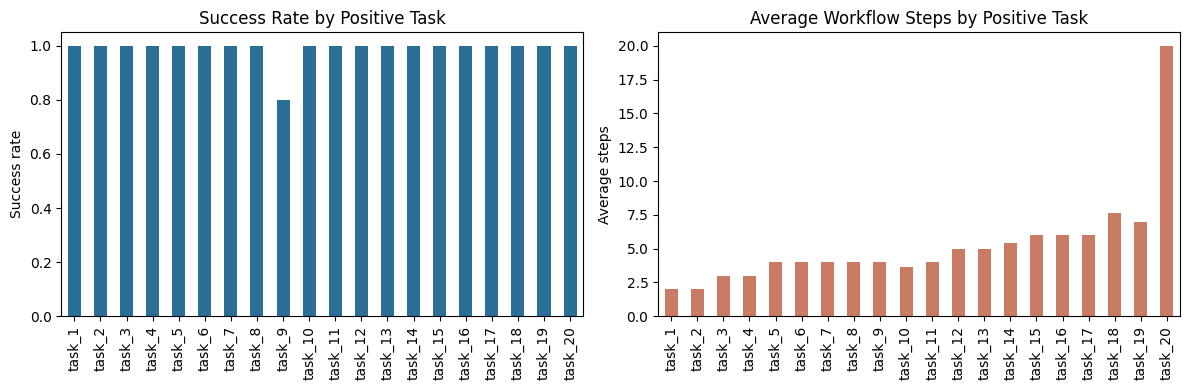

In [5]:
#| hide-code

plot_df = positive_df[["success_rate", "avg_workflow_steps", "avg_test_retries"]].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df["success_rate"].plot(kind="bar", ax=axes[0], color="#2a6f97")
axes[0].set_title("Success Rate by Positive Task")
axes[0].set_ylabel("Success rate")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.05)

plot_df["avg_workflow_steps"].plot(kind="bar", ax=axes[1], color="#c97b63")
axes[1].set_title("Average Workflow Steps by Positive Task")
axes[1].set_ylabel("Average steps")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()


### Interpretation

These results support a narrow claim about schema-first workflow synthesis, not a broad claim about general autonomous planning.

Explicit schemas appear to help in two ways: they guide tool selection and they make the assembled workflow testable as a composed typed object.

Capability boundaries also appear legible to the planner: unsupported tasks were rejected consistently instead of being forced into hallucinated workflows.


In [6]:
#| hide-code

duration_summary = (
    results_df.groupby("task_id")["duration_s"]
    .agg(["mean", "min", "max"])
    .round(1)
    .rename(columns={"mean": "avg_duration_s", "min": "min_duration_s", "max": "max_duration_s"})
)
duration_summary.loc[["task_9", "task_20", "task_21", "task_22", "task_23", "task_24", "task_25"]]


,avg_duration_s,min_duration_s,max_duration_s
task_id,,,
task_9,2517.0,1185.7,2972.0
task_20,2848.0,2688.9,2965.0
task_21,1366.9,1098.1,1518.4
task_22,1247.0,917.1,1407.2
task_23,1365.8,1244.9,1481.4
task_24,1222.3,1082.8,1502.5
task_25,1311.5,973.2,1500.0


The duration slice adds one practical nuance. Unsupported tasks were not immediate cheap exits in the stored runs; the system still spent planning effort before concluding that no valid workflow existed. That suggests a next optimization target for this style of system: faster impossibility detection based on missing schema-level capabilities.


## Conclusions

### Takeaways

The benchmark supports a limited but meaningful claim: when tools are exposed through explicit input and output schemas, an LLM can often synthesize a correct simple linear workflow by stacking those tools into a larger typed procedure.

In the stored benchmark, that claim is supported by strong performance on the positive task set, zero benchmark-case failures among completed workflows, and consistent rejection of unsupported tasks.

### Next Steps

Test the same idea under harder conditions: noisier tools, more ambiguous schemas, branching workflows, and live side effects.

Compare WAA against a plain tool-calling baseline so the value of explicit workflow assembly is measured rather than assumed.


## Appendix

### Links

- Benchmark harness: `artifacts/workflow_auto_assembler/examples/run_benchmark.py`
- Task definitions: `artifacts/workflow_auto_assembler/examples/test_examples.py`
- Template: `artifacts/workflow_auto_assembler/research_notes_template.md`

### Raw Results

- `artifacts/workflow_auto_assembler/test_results/benchmark_results.json`
- `artifacts/workflow_auto_assembler/test_results/benchmark_summary.json`

### Commands

- Re-run the benchmark with `artifacts/workflow_auto_assembler/examples/run_benchmark.py`.
